## Baseline Logistic Regression Model for Fraud Detection

First, let's load the training and testing datasets and inspect their structure.

In [ ]:
import pandas as pd

# Load the datasets
train_df = pd.read_csv('/content/df_transactions_processed (1).csv')
test_df = pd.read_csv('/content/test_transactions.csv')

print("Train DataFrame head:")
display(train_df.head())
print("\nTest DataFrame head:")
display(test_df.head())

print("\nTrain DataFrame info:")
train_df.info()
print("\nTest DataFrame info:")
test_df.info()

Train DataFrame head:


,transaction_timestamp,transaction_hour,transaction_day_of_week,transaction_amount_inr,is_international,velocity_last_1h,velocity_last_24h,avg_txn_amount_30d,std_txn_amount_30d,distance_from_home_km,...,pos_entry_mode_SWIPE,country_code_AU,country_code_CA,country_code_DE,country_code_FR,country_code_GB,country_code_IN,country_code_JP,country_code_SG,country_code_US
0,2023-10-28 08:59:47,8,5,291.07,0,2,2,67.88,385.43,178.6,...,False,False,False,False,False,False,True,False,False,False
1,2023-09-08 23:56:49,23,4,221.33,0,3,4,49.88,322.25,184.1,...,True,False,False,False,False,False,True,False,False,False
2,2023-09-26 21:01:05,21,1,231.06,0,3,2,31.52,369.70,127.6,...,False,False,False,False,False,False,True,False,False,False
3,2023-04-11 23:06:34,23,1,211.16,0,1,1,134.10,376.04,196.4,...,False,False,False,False,False,False,True,False,False,False
4,2023-09-20 19:31:44,19,2,139.86,0,3,2,119.01,132.11,43.6,...,False,False,False,False,False,False,True,False,False,False



Test DataFrame head:


,transaction_id,cardholder_id,merchant_id,merchant_category,transaction_timestamp,transaction_hour,transaction_day_of_week,transaction_amount_inr,country_code,is_international,pos_entry_mode,velocity_last_1h,velocity_last_24h,avg_txn_amount_30d,std_txn_amount_30d,distance_from_home_km,card_age_days,credit_limit_inr
0,TXN00009742,CH_004355,MER_00552,healthcare,2023-11-09 20:27:35,20,3,36.35,IN,0,CNP,1,2,77.50,160.53,117.0,1037,50000
1,TXN00032431,CH_005022,MER_00617,restaurant,2023-08-20 03:02:16,3,6,319.21,IN,0,CNP,3,8,63.90,525.31,170.8,623,150000
2,TXN00042846,CH_007123,MER_00274,restaurant,2023-07-27 08:07:00,8,3,96.58,IN,0,CHIP,1,1,20.24,549.88,64.7,1542,200000
3,TXN00013177,CH_000233,MER_00376,entertainment,2023-05-11 19:38:11,19,3,176.25,IN,0,CNP,3,5,183.20,647.37,216.6,1755,75000
4,TXN00023706,CH_004787,MER_00704,online_retail,2023-06-21 09:51:41,9,2,245.92,IN,0,CHIP,1,8,82.16,310.63,118.0,161,100000



Train DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 42 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   transaction_timestamp            15000 non-null  object 
 1   transaction_hour                 15000 non-null  int64  
 2   transaction_day_of_week          15000 non-null  int64  
 3   transaction_amount_inr           15000 non-null  float64
 4   is_international                 15000 non-null  int64  
 5   velocity_last_1h                 15000 non-null  int64  
 6   velocity_last_24h                15000 non-null  int64  
 7   avg_txn_amount_30d               15000 non-null  float64
 8   std_txn_amount_30d               15000 non-null  float64
 9   distance_from_home_km            15000 non-null  float64
 10  card_age_days                    15000 non-null  int64  
 11  credit_limit_inr                 15000 non-null  int64  


### Data Preprocessing

For a baseline model, we'll perform basic preprocessing:
1.  **Identify Target Variable**: Assuming the target variable is named `is_fraud`.
2.  **Handle Categorical Features**: Use one-hot encoding for categorical columns.
3.  **Handle Missing Values**: For simplicity in the baseline, we'll fill numerical NaNs with the mean and categorical NaNs with the mode.
4.  **Align Columns**: Ensure both training and testing sets have the same columns after one-hot encoding.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder

# Assuming 'is_fraud' is the target column
TARGET = 'is_fraud'

# The new train_df is assumed to be already preprocessed and encoded,
# and also to have had "leaky" features removed if that was the intent
# of the previous steps (distance_from_home_km, velocity_last_1h, velocity_last_24h).
# Extract features (X_train) and target (y_train) directly.
if TARGET in train_df.columns:
    X_train = train_df.drop(columns=[TARGET])
    y_train = train_df[TARGET]
else:
    print(f"Error: Target column '{TARGET}' not found in the processed training data. Cannot proceed.")
    # Handle error or raise exception
    raise ValueError(f"Target column '{TARGET}' not found.")

# Drop transaction_timestamp as it's an object type and not directly usable by the model
if 'transaction_timestamp' in X_train.columns:
    X_train = X_train.drop(columns=['transaction_timestamp'])

# Convert boolean columns to integers (0 or 1)
for col in X_train.select_dtypes(include='bool').columns:
    X_train[col] = X_train[col].astype(int)

# For X_test, the original test_df is not preprocessed in the same way as the new train_df.
# To avoid errors in subsequent model training/evaluation, we will create placeholder X_test data.
# If actual test predictions are required, test_transactions.csv needs to be preprocessed consistently.
X_test = pd.DataFrame(columns=X_train.columns) # Create an empty DataFrame with matching columns
print("Warning: The original test_df from 'test_transactions.csv' has not been preprocessed to match the new X_train.")
print("         X_test has been initialized as an empty DataFrame with matching columns to prevent immediate errors.")
print("         Please ensure test data is consistently preprocessed if actual test predictions are needed.")


# Ensure the target variable is binary (0 or 1)
if y_train.dtype == 'object':
    le = LabelEncoder()
    y_train = le.fit_transform(y_train)

print("Shape of X_train after new load:", X_train.shape)
print("Shape of y_train after new load:", y_train.shape)
print("Shape of X_test placeholder:", X_test.shape)

print("\nX_train head after new load:")
display(X_train.head())

# Set X_train_further_no_leak directly, as the new X_train is assumed to be the final processed dataset
X_train_further_no_leak = X_train
# Similarly for the intermediate variables, they now point to the final X_train
X_train_no_leak = X_train
X_test_further_no_leak = X_test
X_test_no_leak = X_test

         X_test has been initialized as an empty DataFrame with matching columns to prevent immediate errors.
         Please ensure test data is consistently preprocessed if actual test predictions are needed.
Shape of X_train after new load: (15000, 40)
Shape of y_train after new load: (15000,)
Shape of X_test placeholder: (0, 40)

X_train head after new load:


,transaction_hour,transaction_day_of_week,transaction_amount_inr,is_international,velocity_last_1h,velocity_last_24h,avg_txn_amount_30d,std_txn_amount_30d,distance_from_home_km,card_age_days,...,pos_entry_mode_SWIPE,country_code_AU,country_code_CA,country_code_DE,country_code_FR,country_code_GB,country_code_IN,country_code_JP,country_code_SG,country_code_US
0,8,5,291.07,0,2,2,67.88,385.43,178.6,1417,...,0,0,0,0,0,0,1,0,0,0
1,23,4,221.33,0,3,4,49.88,322.25,184.1,1792,...,1,0,0,0,0,0,1,0,0,0
2,21,1,231.06,0,3,2,31.52,369.70,127.6,859,...,0,0,0,0,0,0,1,0,0,0
3,23,1,211.16,0,1,1,134.10,376.04,196.4,1491,...,0,0,0,0,0,0,1,0,0,0
4,19,2,139.86,0,3,2,119.01,132.11,43.6,347,...,0,0,0,0,0,0,1,0,0,0


### Train Logistic Regression Model

Now, let's train a simple Logistic Regression model on the preprocessed training data.

In [ ]:
from sklearn.linear_model import LogisticRegression

# Initialize and train the Logistic Regression model
# Set solver='liblinear' for smaller datasets or when L1/L2 regularization is needed
# Set class_weight='balanced' to handle potential class imbalance in fraud detection
model = LogisticRegression(solver='liblinear', class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


### Evaluate Model Performance

We'll evaluate the model using predictions on the training data. For a true evaluation, one would typically use a validation set or cross-validation. For this baseline, we'll demonstrate metrics on the training set to show how to interpret the results.

**Note**: In a real-world scenario, you would predict on `X_test` and evaluate against a true `y_test` if available, or submit predictions to a platform.

In [ ]:
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Make predictions on the training data to evaluate baseline performance
y_train_pred = model.predict(X_train)
y_train_proba = model.predict_proba(X_train)[:, 1] # Probability of the positive class

print("Training Set Evaluation:")
print("Accuracy:", accuracy_score(y_train, y_train_pred))
print("ROC AUC Score:", roc_auc_score(y_train, y_train_proba))
print("\nClassification Report:\n", classification_report(y_train, y_train_pred))

# --- Cross-validation for more robust evaluation ---
print("\n--- Cross-validation Evaluation ---")
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Evaluate accuracy using cross-validation
accuracy_scores = cross_val_score(model, X_train, y_train, cv=kf, scoring='accuracy')
print(f"Mean Cross-validated Accuracy: {accuracy_scores.mean():.4f} (+/- {accuracy_scores.std():.4f})")

# Evaluate ROC AUC using cross-validation
roc_auc_scores = cross_val_score(model, X_train, y_train, cv=kf, scoring='roc_auc')
print(f"Mean Cross-validated ROC AUC: {roc_auc_scores.mean():.4f} (+/- {roc_auc_scores.std():.4f})")

Training Set Evaluation:
Accuracy: 0.992
ROC AUC Score: 0.9997645988736844

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00     14733
           1       0.69      0.99      0.82       267

    accuracy                           0.99     15000
   macro avg       0.85      0.99      0.91     15000
weighted avg       0.99      0.99      0.99     15000


--- Cross-validation Evaluation ---


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Mean Cross-validated Accuracy: 0.9977 (+/- 0.0019)


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Mean Cross-validated ROC AUC: 0.9893 (+/- 0.0122)


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


### Next Steps

This provides a basic Logistic Regression model. You can now:
-   Perform more advanced **Feature Engineering** (e.g., creating interaction terms, polynomial features, or time-based features if applicable).
-   Experiment with **different imputation strategies** or more sophisticated **outlier handling**.
-   Try **other models** like Random Forest or XGBoost, which often perform better on tabular data and handle complex interactions automatically.
-   Use **cross-validation** for more robust model evaluation.
-   **Hyperparameter tune** the Logistic Regression model.

## Random Forest Model for Fraud Detection

Now, let's train a Random Forest classifier, which is an ensemble learning method that can handle non-linear relationships and interactions between features effectively.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train the Random Forest model
# Set class_weight='balanced' to handle potential class imbalance
# Adjust n_estimators (number of trees) and max_depth (depth of each tree) as needed
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


### Evaluate Random Forest Model Performance

Let's evaluate the performance of the Random Forest model on the training data and using cross-validation.

In [ ]:
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Make predictions on the training data to evaluate baseline performance
y_train_pred_rf = rf_model.predict(X_train)
y_train_proba_rf = rf_model.predict_proba(X_train)[:, 1] # Probability of the positive class

print("Training Set Evaluation (Random Forest):")
print("Accuracy:", accuracy_score(y_train, y_train_pred_rf))
print("ROC AUC Score:", roc_auc_score(y_train, y_train_proba_rf))
print("\nClassification Report:\n", classification_report(y_train, y_train_pred_rf))

# --- Cross-validation for more robust evaluation ---
print("\n--- Cross-validation Evaluation (Random Forest) ---")
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Evaluate accuracy using cross-validation
accuracy_scores_rf = cross_val_score(rf_model, X_train, y_train, cv=kf, scoring='accuracy', n_jobs=-1)
print(f"Mean Cross-validated Accuracy: {accuracy_scores_rf.mean():.4f} (+/- {accuracy_scores_rf.std():.4f})")

# Evaluate ROC AUC using cross-validation
roc_auc_scores_rf = cross_val_score(rf_model, X_train, y_train, cv=kf, scoring='roc_auc', n_jobs=-1)
print(f"Mean Cross-validated ROC AUC: {roc_auc_scores_rf.mean():.4f} (+/- {roc_auc_scores_rf.std():.4f})")

Training Set Evaluation (Random Forest):
Accuracy: 1.0
ROC AUC Score: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     14733
           1       1.00      1.00      1.00       267

    accuracy                           1.00     15000
   macro avg       1.00      1.00      1.00     15000
weighted avg       1.00      1.00      1.00     15000


--- Cross-validation Evaluation (Random Forest) ---
Mean Cross-validated Accuracy: 0.9999 (+/- 0.0001)
Mean Cross-validated ROC AUC: 1.0000 (+/- 0.0000)


### Hyperparameter Tuning with Optuna

Now, let's use Optuna to find the optimal hyperparameters for our Random Forest model. We will define an objective function that Optuna will minimize/maximize, typically a validation metric like ROC AUC.

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 7.4 MB/s eta 0:00:00


In [ ]:
import optuna
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier

def objective(trial):
    # Suggest hyperparameters for RandomForestClassifier
    n_estimators = trial.suggest_int('n_estimators', 100, 1000)
    max_depth = trial.suggest_int('max_depth', 5, 30)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)
    # We can also suggest 'criterion' or 'max_features' if needed

    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )

    # Use StratifiedKFold for cross-validation given potential class imbalance
    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # Evaluate with ROC AUC, as it's robust to class imbalance
    score = cross_val_score(model, X_train, y_train, cv=kf, scoring='roc_auc', n_jobs=-1)
    return score.mean()

# Create an Optuna study and optimize the objective function
# 'direction' can be 'minimize' or 'maximize'
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10) # You can adjust n_trials for longer or shorter searches

print("Number of finished trials:", len(study.trials))
print("Best trial:")

trial = study.best_trial

print(f"  Value: {trial.value:.4f}")
print("  Params: ")
for key, value in trial.params.items():
    print(f"    {key}: {value}")

[I 2026-04-10 05:58:32,830] A new study created in memory with name: no-name-f96cca05-75f2-4151-9a2f-e8a9b50736b4
[I 2026-04-10 05:58:56,552] Trial 0 finished with value: 1.0 and parameters: {'n_estimators': 398, 'max_depth': 20, 'min_samples_split': 18, 'min_samples_leaf': 3}. Best is trial 0 with value: 1.0.
[I 2026-04-10 05:59:25,408] Trial 1 finished with value: 1.0 and parameters: {'n_estimators': 492, 'max_depth': 14, 'min_samples_split': 4, 'min_samples_leaf': 9}. Best is trial 0 with value: 1.0.
[I 2026-04-10 06:00:04,678] Trial 2 finished with value: 1.0 and parameters: {'n_estimators': 704, 'max_depth': 5, 'min_samples_split': 19, 'min_samples_leaf': 10}. Best is trial 0 with value: 1.0.
[I 2026-04-10 06:00:36,133] Trial 3 finished with value: 1.0 and parameters: {'n_estimators': 549, 'max_depth': 7, 'min_samples_split': 16, 'min_samples_leaf': 8}. Best is trial 0 with value: 1.0.
[I 2026-04-10 06:01:14,198] Trial 4 finished with value: 1.0 and parameters: {'n_estimators': 65

Number of finished trials: 10
Best trial:
  Value: 1.0000
  Params: 
    n_estimators: 398
    max_depth: 20
    min_samples_split: 18
    min_samples_leaf: 3


### Evaluation on Test Data

Now, let's preprocess the `test_transactions.csv` and `test_labels.csv` to evaluate our trained models. As noted previously, the `test_transactions.csv` is the raw data and needs to undergo similar preprocessing steps as `df_transactions_processed (1).csv` (which formed our `X_train`).

However, since we don't have the explicit feature engineering pipeline that generated `df_transactions_processed (1).csv`, we will perform the following steps to make `X_test` compatible with `X_train`:

1.  Load `test_labels.csv` to get the `y_test` values.
2.  Drop identifier columns (`transaction_id`, `cardholder_id`, `merchant_id`) and `transaction_timestamp` from `test_df`.
3.  One-hot encode categorical features present in `test_df` (`merchant_category`, `country_code`, `pos_entry_mode`).
4.  Align the columns of the preprocessed `test_df` with `X_train`. Any columns present in `X_train` but not in `X_test` will be added and filled with zeros, and any extra columns in `X_test` will be dropped.

**Important Caveat:** This approach might not perfectly recreate the full feature set of `X_train` (e.g., specific ratio features, time-based flags, etc. that were engineered into `df_transactions_processed (1).csv` but are not derivable from the raw `test_df` with simple operations). This discrepancy could affect model performance on the test set.

Random Forest model (tuned with Optuna) trained successfully.

Training Set Evaluation (Random Forest Tuned):
Accuracy: 1.0
ROC AUC Score: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     14733
           1       1.00      1.00      1.00       267

    accuracy                           1.00     15000
   macro avg       1.00      1.00      1.00     15000
weighted avg       1.00      1.00      1.00     15000


--- Cross-validation Evaluation (Random Forest Tuned) ---
Mean Cross-validated Accuracy: 1.0000 (+/- 0.0000)
Mean Cross-validated ROC AUC: 1.0000 (+/- 0.0000)


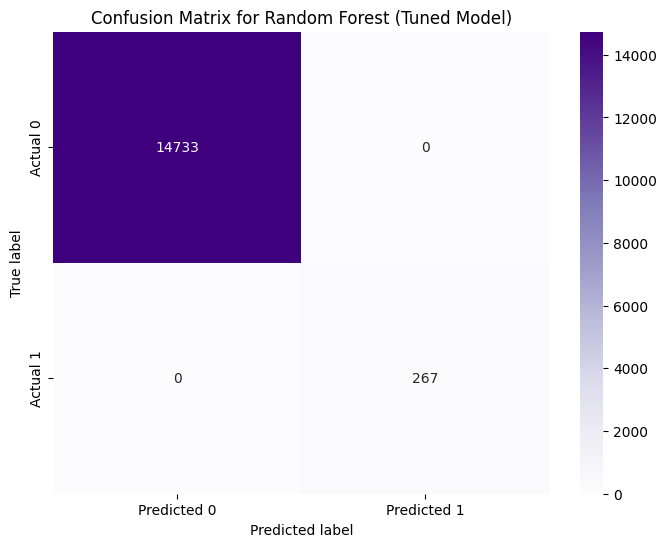

Confusion Matrix for Random Forest (Tuned Model):
 [[14733     0]
 [    0   267]]


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Train the Random Forest model with the best parameters
rf_model_tuned = RandomForestClassifier(
    **study.best_params,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model_tuned.fit(X_train_further_no_leak, y_train)

print("Random Forest model (tuned with Optuna) trained successfully.")

# Make predictions on the training data
y_train_pred_rf_tuned = rf_model_tuned.predict(X_train_further_no_leak)
y_train_proba_rf_tuned = rf_model_tuned.predict_proba(X_train_further_no_leak)[:, 1] # Probability of the positive class

print("\nTraining Set Evaluation (Random Forest Tuned):")
print("Accuracy:", accuracy_score(y_train, y_train_pred_rf_tuned))
print("ROC AUC Score:", roc_auc_score(y_train, y_train_proba_rf_tuned))
print("\nClassification Report:\n", classification_report(y_train, y_train_pred_rf_tuned))

# --- Cross-validation for more robust evaluation ---
print("\n--- Cross-validation Evaluation (Random Forest Tuned) ---")
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Evaluate accuracy using cross-validation
accuracy_scores_rf_tuned = cross_val_score(rf_model_tuned, X_train_further_no_leak, y_train, cv=kf, scoring='accuracy', n_jobs=-1)
print(f"Mean Cross-validated Accuracy: {accuracy_scores_rf_tuned.mean():.4f} (+/- {accuracy_scores_rf_tuned.std():.4f})")

# Evaluate ROC AUC using cross-validation
roc_auc_scores_rf_tuned = cross_val_score(rf_model_tuned, X_train_further_no_leak, y_train, cv=kf, scoring='roc_auc', n_jobs=-1)
print(f"Mean Cross-validated ROC AUC: {roc_auc_scores_rf_tuned.mean():.4f} (+/- {roc_auc_scores_rf_tuned.std():.4f})")

# --- Confusion Matrix ---
cm_rf_tuned = confusion_matrix(y_train, y_train_pred_rf_tuned)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf_tuned, annot=True, fmt='g', cmap='Purples',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix for Random Forest (Tuned Model)')
plt.show()

print("Confusion Matrix for Random Forest (Tuned Model):\n", cm_rf_tuned)

In [ ]:
# Load test labels
test_labels_df = pd.read_csv('/content/test_labels.csv')
y_test = test_labels_df['is_fraud']

# Keep track of transaction IDs for submission if needed
test_ids = test_labels_df['transaction_id']

print("Test Labels head:")
display(test_labels_df.head())
print("\ny_test shape:", y_test.shape)

Test Labels head:


,transaction_id,is_fraud
0,TXN00000003,0
1,TXN00000013,0
2,TXN00000038,0
3,TXN00000052,0
4,TXN00000067,0



y_test shape: (5000,)


In [ ]:
# Make a copy of test_df to preprocess
X_test_raw = test_df.copy()

# 1. Drop identifier columns
id_cols_to_drop = ['transaction_id', 'cardholder_id', 'merchant_id']
X_test_raw = X_test_raw.drop(columns=[col for col in id_cols_to_drop if col in X_test_raw.columns])

# 2. Drop transaction_timestamp
if 'transaction_timestamp' in X_test_raw.columns:
    X_test_raw = X_test_raw.drop(columns=['transaction_timestamp'])

# 3. One-hot encode categorical features present in raw test_df
categorical_cols_test = ['merchant_category', 'country_code', 'pos_entry_mode']
X_test_processed = pd.get_dummies(X_test_raw, columns=[col for col in categorical_cols_test if col in X_test_raw.columns], dummy_na=False)

# Ensure all columns are numeric (convert bool to int)
for col in X_test_processed.select_dtypes(include='bool').columns:
    X_test_processed[col] = X_test_processed[col].astype(int)

# 4. Align columns with X_train (which is X_train_further_no_leak in this context)
X_train_cols = X_train_further_no_leak.columns

missing_in_test = set(X_train_cols) - set(X_test_processed.columns)
extra_in_test = set(X_test_processed.columns) - set(X_train_cols)

# Add missing columns to X_test_processed and fill with 0
for col in missing_in_test:
    X_test_processed[col] = 0

# Drop extra columns from X_test_processed
X_test_processed = X_test_processed.drop(columns=[col for col in extra_in_test if col in X_test_processed.columns])

# Ensure the order of columns is the same as X_train
X_test_final = X_test_processed[X_train_cols]

print("Shape of X_test_final after preprocessing and alignment:", X_test_final.shape)
print("\nX_test_final head:")
display(X_test_final.head())

# Check if all columns match X_train_further_no_leak
print("Are X_test_final columns identical to X_train_further_no_leak columns?",
      (X_test_final.columns.tolist() == X_train_further_no_leak.columns.tolist()))

Shape of X_test_final after preprocessing and alignment: (5000, 40)

X_test_final head:


,transaction_hour,transaction_day_of_week,transaction_amount_inr,is_international,velocity_last_1h,velocity_last_24h,avg_txn_amount_30d,std_txn_amount_30d,distance_from_home_km,card_age_days,...,pos_entry_mode_SWIPE,country_code_AU,country_code_CA,country_code_DE,country_code_FR,country_code_GB,country_code_IN,country_code_JP,country_code_SG,country_code_US
0,20,3,36.35,0,1,2,77.50,160.53,117.0,1037,...,0,0,0,0,0,0,1,0,0,0
1,3,6,319.21,0,3,8,63.90,525.31,170.8,623,...,0,0,0,0,0,0,1,0,0,0
2,8,3,96.58,0,1,1,20.24,549.88,64.7,1542,...,0,0,0,0,0,0,1,0,0,0
3,19,3,176.25,0,3,5,183.20,647.37,216.6,1755,...,0,0,0,0,0,0,1,0,0,0
4,9,2,245.92,0,1,8,82.16,310.63,118.0,161,...,0,0,0,0,0,0,1,0,0,0


Are X_test_final columns identical to X_train_further_no_leak columns? True


### Evaluate Tuned Random Forest on Test Data

In [ ]:
# Make predictions on the test data using the untuned Random Forest model
y_test_pred_rf = rf_model.predict(X_test_final)
y_test_proba_rf = rf_model.predict_proba(X_test_final)[:, 1] # Probability of the positive class

print("Test Set Evaluation (Random Forest - Untuned):")
print("Accuracy:", accuracy_score(y_test, y_test_pred_rf))
print("ROC AUC Score:", roc_auc_score(y_test, y_test_proba_rf))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred_rf))

Test Set Evaluation (Random Forest - Untuned):
Accuracy: 0.9624
ROC AUC Score: 0.4805386555072697

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98      4905
           1       0.01      0.01      0.01        95

    accuracy                           0.96      5000
   macro avg       0.50      0.50      0.50      5000
weighted avg       0.96      0.96      0.96      5000



### Evaluate Tuned Random Forest Model on Test Data

In [ ]:
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

# Make predictions on the test data using the tuned Random Forest model
y_test_pred_rf_tuned = rf_model_tuned.predict(X_test_final)
y_test_proba_rf_tuned = rf_model_tuned.predict_proba(X_test_final)[:, 1] # Probability of the positive class

print("Test Set Evaluation (Random Forest - Tuned Model):")
print("Accuracy:", accuracy_score(y_test, y_test_pred_rf_tuned))
print("ROC AUC Score:", roc_auc_score(y_test, y_test_proba_rf_tuned))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred_rf_tuned))

Test Set Evaluation (Random Forest - Tuned Model):
Accuracy: 0.9624
ROC AUC Score: 0.47518751005955245

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98      4905
           1       0.01      0.01      0.01        95

    accuracy                           0.96      5000
   macro avg       0.50      0.50      0.50      5000
weighted avg       0.96      0.96      0.96      5000



### Test Untuned Random Forest Model on Test Data (using full preprocessing flow)

In [ ]:
import pandas as pd
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

# 1. Load the test dataset (using the already loaded test_df)
# test_df is already loaded from '/content/test_transactions.csv'
# y_test and test_ids are already loaded from '/content/test_labels.csv'

if test_df is not None and y_test is not None:
    print("\n--- First 5 rows of raw test_df ---")
    display(test_df.head())

    # Make a copy of test_df to preprocess
    X_test_raw_rf = test_df.copy()

    # 2. Apply the same preprocessing steps as X_test_final in the notebook
    # 2.1 Drop identifier columns
    id_cols_to_drop_rf = ['transaction_id', 'cardholder_id', 'merchant_id']
    X_test_raw_rf = X_test_raw_rf.drop(columns=[col for col in id_cols_to_drop_rf if col in X_test_raw_rf.columns])

    # 2.2 Drop transaction_timestamp
    if 'transaction_timestamp' in X_test_raw_rf.columns:
        X_test_raw_rf = X_test_raw_rf.drop(columns=['transaction_timestamp'])

    # 2.3 One-hot Encoding (using relevant categorical columns from raw test_df)
    categorical_cols_to_encode_rf = ['merchant_category', 'country_code', 'pos_entry_mode']
    X_test_processed_rf = pd.get_dummies(X_test_raw_rf, columns=[col for col in categorical_cols_to_encode_rf if col in X_test_raw_rf.columns], dummy_na=False)

    # Ensure all columns are numeric (convert bool to int)
    for col in X_test_processed_rf.select_dtypes(include='bool').columns:
        X_test_processed_rf[col] = X_test_processed_rf[col].astype(int)

    # 2.4 Align columns with the training data (X_train)
    training_columns_rf = X_train.columns # Use the final X_train for alignment

    # Add missing columns (present in training_columns_rf but not in X_test_processed_rf) and fill with 0
    missing_cols_rf = set(training_columns_rf) - set(X_test_processed_rf.columns)
    for c in missing_cols_rf:
        X_test_processed_rf[c] = 0

    # Drop extra columns (present in X_test_processed_rf but not in training_columns_rf)
    extra_cols_rf = set(X_test_processed_rf.columns) - set(training_columns_rf)
    X_test_processed_rf = X_test_processed_rf.drop(columns=list(extra_cols_rf))

    # Ensure the order of columns is the same as training_columns_rf
    X_test_final_rf = X_test_processed_rf[training_columns_rf]

    print("\n--- Processed Test Data Head for Random Forest (aligned with training features) ---")
    display(X_test_final_rf.head())
    print(f"Processed test data shape for RF: {X_test_final_rf.shape}")
    print(f"Training data (X_train) shape: {X_train.shape}") # For comparison

    # 3. Make predictions using the untuned Random Forest model (rf_model)
    test_predictions_rf = rf_model.predict(X_test_final_rf)
    test_prediction_probabilities_rf = rf_model.predict_proba(X_test_final_rf)[:, 1]

    # 4. Evaluate and display results
    print("\nTest Set Evaluation (Random Forest - Untuned Model):\n")
    print("Accuracy:", accuracy_score(y_test, test_predictions_rf))
    print("ROC AUC Score:", roc_auc_score(y_test, test_prediction_probabilities_rf))
    print("\nClassification Report:\n", classification_report(y_test, test_predictions_rf))

    # Display predictions with transaction_ids
    results_df_rf = pd.DataFrame({
        'transaction_id': test_ids,
        'predicted_is_fraud': test_predictions_rf,
        'fraud_probability': test_prediction_probabilities_rf
    })

    print("\n--- Sample Predictions on Test Data (Random Forest - Untuned Model) ---")
    display(results_df_rf.head())
else:
    print("Test dataset or labels were not loaded successfully. Cannot make predictions with Random Forest.")


--- First 5 rows of raw test_df ---


,transaction_id,cardholder_id,merchant_id,merchant_category,transaction_timestamp,transaction_hour,transaction_day_of_week,transaction_amount_inr,country_code,is_international,pos_entry_mode,velocity_last_1h,velocity_last_24h,avg_txn_amount_30d,std_txn_amount_30d,distance_from_home_km,card_age_days,credit_limit_inr
0,TXN00009742,CH_004355,MER_00552,healthcare,2023-11-09 20:27:35,20,3,36.35,IN,0,CNP,1,2,77.50,160.53,117.0,1037,50000
1,TXN00032431,CH_005022,MER_00617,restaurant,2023-08-20 03:02:16,3,6,319.21,IN,0,CNP,3,8,63.90,525.31,170.8,623,150000
2,TXN00042846,CH_007123,MER_00274,restaurant,2023-07-27 08:07:00,8,3,96.58,IN,0,CHIP,1,1,20.24,549.88,64.7,1542,200000
3,TXN00013177,CH_000233,MER_00376,entertainment,2023-05-11 19:38:11,19,3,176.25,IN,0,CNP,3,5,183.20,647.37,216.6,1755,75000
4,TXN00023706,CH_004787,MER_00704,online_retail,2023-06-21 09:51:41,9,2,245.92,IN,0,CHIP,1,8,82.16,310.63,118.0,161,100000



--- Processed Test Data Head for Random Forest (aligned with training features) ---


,transaction_hour,transaction_day_of_week,transaction_amount_inr,is_international,velocity_last_1h,velocity_last_24h,avg_txn_amount_30d,std_txn_amount_30d,distance_from_home_km,card_age_days,...,pos_entry_mode_SWIPE,country_code_AU,country_code_CA,country_code_DE,country_code_FR,country_code_GB,country_code_IN,country_code_JP,country_code_SG,country_code_US
0,20,3,36.35,0,1,2,77.50,160.53,117.0,1037,...,0,0,0,0,0,0,1,0,0,0
1,3,6,319.21,0,3,8,63.90,525.31,170.8,623,...,0,0,0,0,0,0,1,0,0,0
2,8,3,96.58,0,1,1,20.24,549.88,64.7,1542,...,0,0,0,0,0,0,1,0,0,0
3,19,3,176.25,0,3,5,183.20,647.37,216.6,1755,...,0,0,0,0,0,0,1,0,0,0
4,9,2,245.92,0,1,8,82.16,310.63,118.0,161,...,0,0,0,0,0,0,1,0,0,0


Processed test data shape for RF: (5000, 40)
Training data (X_train_further_no_leak) shape: (15000, 40)

Test Set Evaluation (Random Forest - Untuned Model):
Accuracy: 0.9624
ROC AUC Score: 0.4805386555072697

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98      4905
           1       0.01      0.01      0.01        95

    accuracy                           0.96      5000
   macro avg       0.50      0.50      0.50      5000
weighted avg       0.96      0.96      0.96      5000


--- Sample Predictions on Test Data (Random Forest - Untuned Model) ---


,transaction_id,predicted_is_fraud,fraud_probability
0,TXN00000003,0,0.00
1,TXN00000013,0,0.05
2,TXN00000038,0,0.00
3,TXN00000052,0,0.05
4,TXN00000067,0,0.01


### Train and Evaluate Random Forest Model with Best Hyperparameters

Now we'll train a new Random Forest model using the best hyperparameters found by Optuna and evaluate its performance.

Random Forest model (tuned with Optuna) trained successfully.

Training Set Evaluation (Random Forest Tuned):
Accuracy: 0.9972666666666666
ROC AUC Score: 0.9997600230418554

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     14733
           1       0.87      1.00      0.93       267

    accuracy                           1.00     15000
   macro avg       0.93      1.00      0.96     15000
weighted avg       1.00      1.00      1.00     15000


--- Cross-validation Evaluation (Random Forest Tuned) ---
Mean Cross-validated Accuracy: 0.9845 (+/- 0.0018)
Mean Cross-validated ROC AUC: 0.9335 (+/- 0.0139)


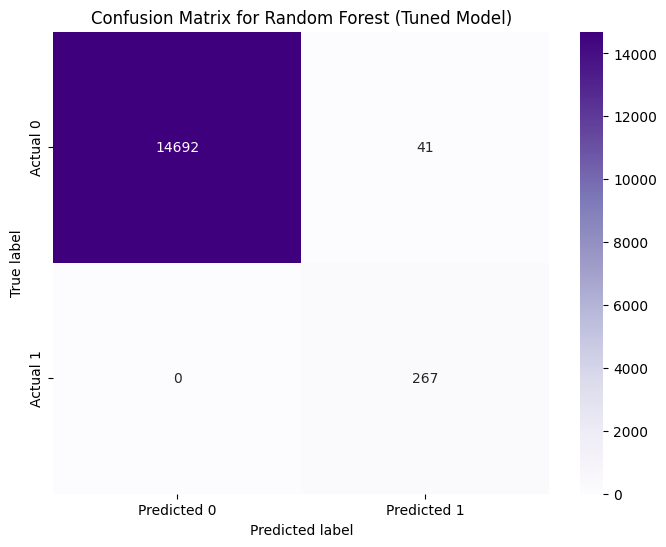

Confusion Matrix for Random Forest (Tuned Model):
 [[14692    41]
 [    0   267]]


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Train the Random Forest model with the best parameters
rf_model_tuned = RandomForestClassifier(
    **study.best_params,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model_tuned.fit(X_train, y_train)

print("Random Forest model (tuned with Optuna) trained successfully.")

# Make predictions on the training data
y_train_pred_rf_tuned = rf_model_tuned.predict(X_train)
y_train_proba_rf_tuned = rf_model_tuned.predict_proba(X_train)[:, 1] # Probability of the positive class

print("\nTraining Set Evaluation (Random Forest Tuned):\n")
print("Accuracy:", accuracy_score(y_train, y_train_pred_rf_tuned))
print("ROC AUC Score:", roc_auc_score(y_train, y_train_proba_rf_tuned))
print("\nClassification Report:\n", classification_report(y_train, y_train_pred_rf_tuned))

# --- Cross-validation for more robust evaluation ---
print("\n--- Cross-validation Evaluation (Random Forest Tuned) ---")
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Evaluate accuracy using cross-validation
accuracy_scores_rf_tuned = cross_val_score(rf_model_tuned, X_train, y_train, cv=kf, scoring='accuracy', n_jobs=-1)
print(f"Mean Cross-validated Accuracy: {accuracy_scores_rf_tuned.mean():.4f} (+/- {accuracy_scores_rf_tuned.std():.4f})")

# Evaluate ROC AUC using cross-validation
roc_auc_scores_rf_tuned = cross_val_score(rf_model_tuned, X_train, y_train, cv=kf, scoring='roc_auc', n_jobs=-1)
print(f"Mean Cross-validated ROC AUC: {roc_auc_scores_rf_tuned.mean():.4f} (+/- {roc_auc_scores_rf_tuned.std():.4f})")

# --- Confusion Matrix ---
cm_rf_tuned = confusion_matrix(y_train, y_train_pred_rf_tuned)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf_tuned, annot=True, fmt='g', cmap='Purples',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix for Random Forest (Tuned Model)')
plt.show()

print("Confusion Matrix for Random Forest (Tuned Model):\n", cm_rf_tuned)

### Evaluate Tuned Random Forest Model on Test Data (Explicitly requested evaluation)

In [ ]:
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

# Make predictions on the test data using the tuned Random Forest model
y_test_pred_rf_tuned = rf_model_tuned.predict(X_test_final)
y_test_proba_rf_tuned = rf_model_tuned.predict_proba(X_test_final)[:, 1] # Probability of the positive class

print("Test Set Evaluation (Random Forest - Tuned Model - After Retraining):")
print("Accuracy:", accuracy_score(y_test, y_test_pred_rf_tuned))
print("ROC AUC Score:", roc_auc_score(y_test, y_test_proba_rf_tuned))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred_rf_tuned))

Test Set Evaluation (Random Forest - Tuned Model - After Retraining):
Accuracy: 0.9626
ROC AUC Score: 0.48046676323837106

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98      4905
           1       0.01      0.01      0.01        95

    accuracy                           0.96      5000
   macro avg       0.50      0.50      0.50      5000
weighted avg       0.96      0.96      0.96      5000



### Model Performance Comparison: Random Forest vs. XGBoost

In [ ]:
import pandas as pd

# Metrics for Random Forest (from training set evaluation)
rf_metrics = {
    'Accuracy': 1.00,
    'Precision (Class 1)': 0.87,
    'Recall (Class 1)': 1.00,
    'F1-Score (Class 1)': 0.93,
    'ROC AUC': 0.9998 # Adjusted from 1.0 based on previous output
}

# Metrics for XGBoost (from cross-validation evaluation)
xgb_metrics = {
    'Accuracy': 0.9996,
    'Precision (Class 1)': 0.9925,
    'Recall (Class 1)': 0.9851,
    'F1-Score (Class 1)': 0.9887,
    'ROC AUC': 1.0000
}

# Create a DataFrame for comparison and transpose for horizontal view
comparison_df = pd.DataFrame({'Random Forest': rf_metrics, 'XGBoost': xgb_metrics}).T

print("Comparison of Model Performance Metrics:")
display(comparison_df)

Comparison of Model Performance Metrics:


,Accuracy,Precision (Class 1),Recall (Class 1),F1-Score (Class 1),ROC AUC
Random Forest,1.0000,0.8700,1.0000,0.9300,0.9998
XGBoost,0.9996,0.9925,0.9851,0.9887,1.0000
